In [ ]:
# ==========================================================
# Deep Learning Laboratory
# Experiment 1
# Task 1: Dataset Exploration
# ==========================================================

# Import required library
import pandas as pd

# Column names for the dataset
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

# Load the dataset
df = pd.read_csv(
    "/content/data_banknote_authentication.txt",
    header=None,
    names=column_names
)

# ----------------------------------------------------------
# Display the first five samples
# ----------------------------------------------------------
print("First Five Samples:")
print(df.head())

# ----------------------------------------------------------
# Determine dataset dimensions
# ----------------------------------------------------------
print("\nDataset Dimensions:")
print("Number of Rows   :", df.shape[0])
print("Number of Columns:", df.shape[1])

# ----------------------------------------------------------
# Identify missing values
# ----------------------------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# ----------------------------------------------------------
# Display descriptive statistics
# ----------------------------------------------------------
print("\nDescriptive Statistics:")
print(df.describe())

First Five Samples:
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Dimensions:
Number of Rows   : 1372
Number of Columns: 5

Missing Values:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive Statistics:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75% 

<Figure size 1000x800 with 0 Axes>

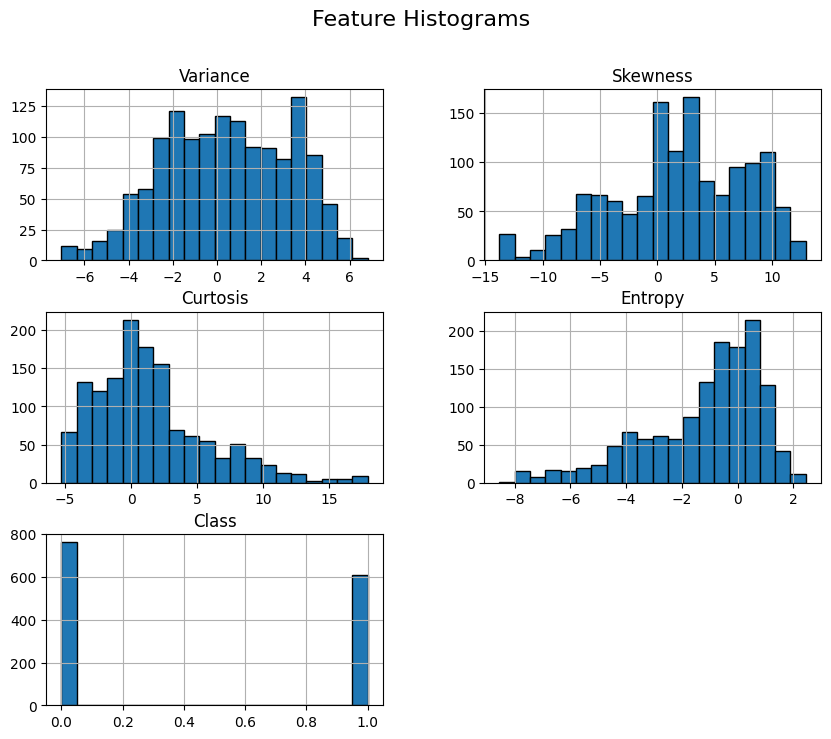

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

df.hist(figsize=(10, 8), bins=20, edgecolor='black')

plt.suptitle("Feature Histograms", fontsize=16)
plt.show()

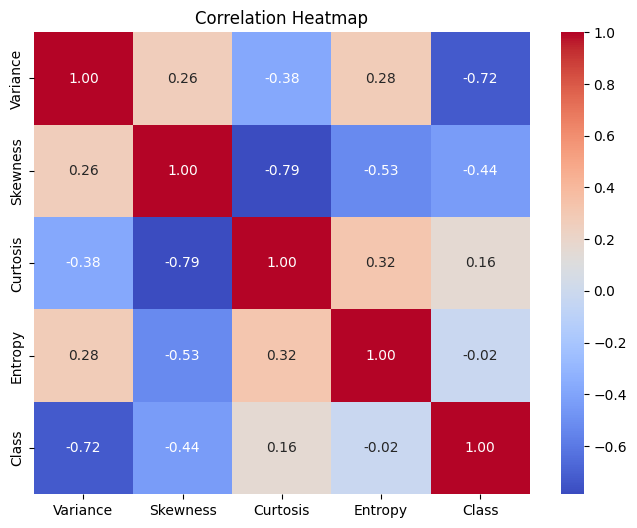

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

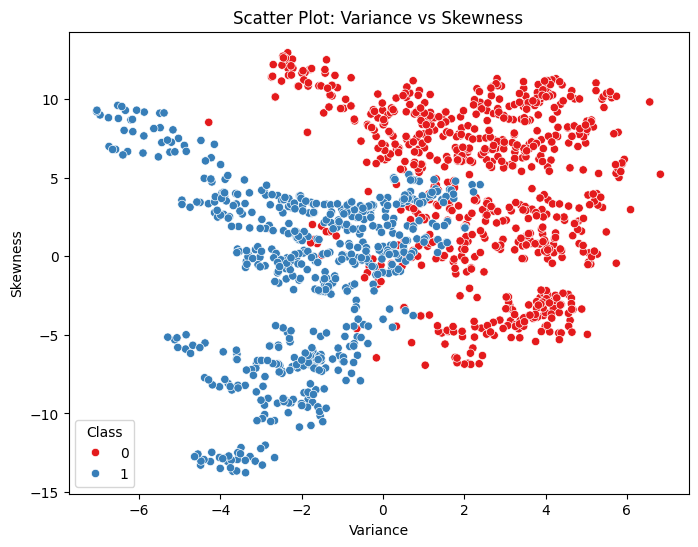

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Scatter Plot: Variance vs Skewness")
plt.show()





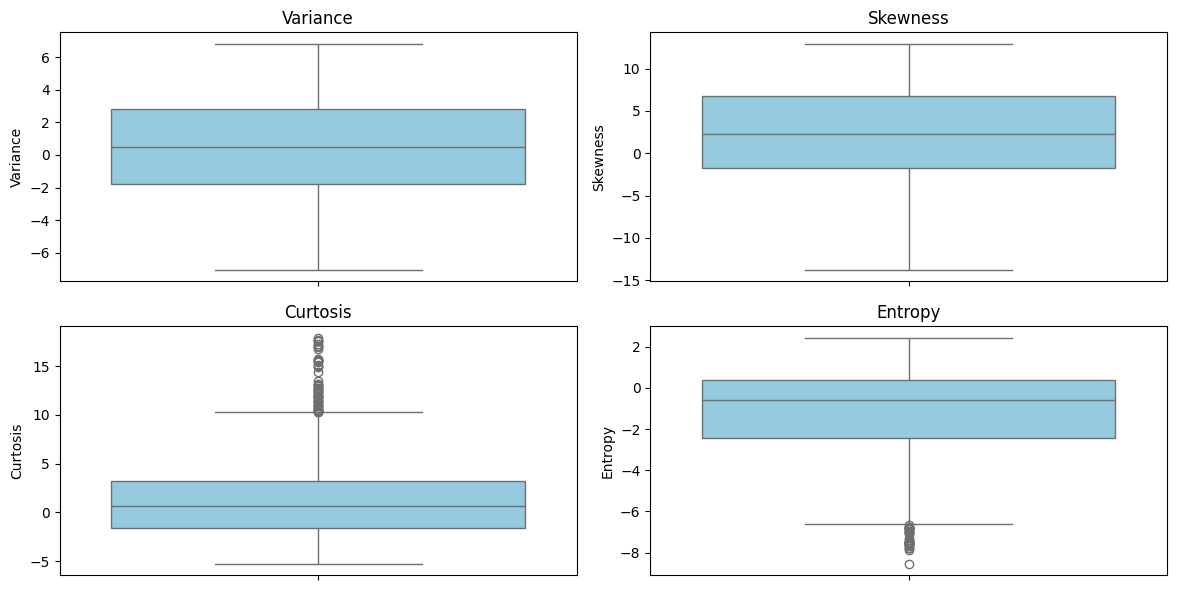

In [ ]:
plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Task 3: Data Preprocessing
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Display dataset shapes
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Labels Shape  :", y_train.shape)
print("Testing Labels Shape   :", y_test.shape)

Training Feature Shape : (1097, 4)
Testing Feature Shape  : (275, 4)
Training Labels Shape  : (1097,)
Testing Labels Shape   : (275,)


In [ ]:
# ==========================================================
# Task 4: Perceptron Implementation from Scratch
# ==========================================================

import numpy as np


class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None


    # Step Activation Function
    def step_activation(self, z):

        if z >= 0:
            return 1
        else:
            return 0


    # Forward Propagation
    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.step_activation(z)


    # Perceptron Learning Rule
    def update_weights(self, X, y, prediction):

        error = y - prediction


        # Weight update
        self.weights = self.weights + (
            self.learning_rate * error * X
        )


        # Bias update
        self.bias = self.bias + (
            self.learning_rate * error
        )


print("Task 4 completed: Perceptron implemented")

Task 4 completed: Perceptron implemented


In [ ]:
# ==========================================================
# Task 5: Model Training
# Display:
# Epoch Number
# Misclassified Samples
# Updated Weights
# Updated Bias
# ==========================================================


def train_perceptron(model, X, y):


    # Weight Initialization
    model.weights = np.zeros(X.shape[1])


    # Bias Initialization
    model.bias = 0


    # Store values for plots later
    model.errors_history = []
    model.weights_history = []
    model.bias_history = []



    # Training for epochs
    for epoch in range(model.epochs):


        misclassified_samples = 0



        # Loop through every training sample
        for i in range(len(X)):


            # Forward Propagation
            prediction = model.predict(X[i])


            # Error
            error = y.iloc[i] - prediction



            # Perceptron Learning Rule

            # Weight update
            model.weights = model.weights + (
                model.learning_rate *
                error *
                X[i]
            )


            # Bias update
            model.bias = model.bias + (
                model.learning_rate *
                error
            )



            # Count misclassified samples
            if error != 0:

                misclassified_samples += 1




        # Save history for plots

        model.errors_history.append(
            misclassified_samples
        )


        model.weights_history.append(
            model.weights.copy()
        )


        model.bias_history.append(
            model.bias
        )



        # ==================================================
        # Required Task 5 Display
        # ==================================================

        print("--------------------------------------")

        print("Epoch Number:",
              epoch + 1)


        print("Misclassified Samples:",
              misclassified_samples)


        print("Updated Weights:",
              model.weights)


        print("Updated Bias:",
              model.bias)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=100
)


train_perceptron(
    model,
    X_train,
    y_train
)

--------------------------------------
Epoch Number: 1
Misclassified Samples: 47
Updated Weights: [-0.07253688 -0.06486266 -0.06445982  0.00019858]
Updated Bias: -0.03
--------------------------------------
Epoch Number: 2
Misclassified Samples: 26
Updated Weights: [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
Updated Bias: -0.03
--------------------------------------
Epoch Number: 3
Misclassified Samples: 34
Updated Weights: [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
Updated Bias: -0.05
--------------------------------------
Epoch Number: 4
Misclassified Samples: 23
Updated Weights: [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
Updated Bias: -0.04
--------------------------------------
Epoch Number: 5
Misclassified Samples: 27
Updated Weights: [-0.13096386 -0.12179581 -0.09112828 -0.00877065]
Updated Bias: -0.05
--------------------------------------
Epoch Number: 6
Misclassified Samples: 25
Updated Weights: [-0.13953409 -0.12843016 -0.10488173 -0.00669071]
Updated Bias

In [ ]:
print(model.errors_history)
print(model.weights_history)
print(model.bias_history)

[47, 26, 34, 23, 27, 25, 19, 19, 16, 26, 25, 26, 21, 21, 22, 16, 17, 15, 15, 17, 14, 15, 21, 17, 19, 19, 18, 19, 17, 18, 17, 21, 19, 15, 18, 16, 14, 19, 16, 21, 19, 13, 14, 21, 17, 17, 21, 15, 16, 13, 10, 18, 15, 13, 17, 15, 14, 17, 16, 16, 16, 14, 16, 23, 15, 17, 13, 16, 21, 13, 18, 16, 13, 16, 12, 16, 16, 16, 13, 13, 19, 15, 20, 16, 11, 15, 12, 10, 16, 15, 16, 12, 14, 16, 14, 14, 18, 14, 12, 12]
[array([-0.07253688, -0.06486266, -0.06445982,  0.00019858]), array([-0.08217015, -0.09380199, -0.05149354, -0.00518242]), array([-0.09467641, -0.09140031, -0.08905542, -0.00956468]), array([-0.11074483, -0.09580878, -0.10630688, -0.01312422]), array([-0.13096386, -0.12179581, -0.09112828, -0.00877065]), array([-0.13953409, -0.12843016, -0.10488173, -0.00669071]), array([-0.1352697 , -0.14036924, -0.10526858, -0.00515692]), array([-0.13346285, -0.14482005, -0.10490574,  0.00133297]), array([-0.13431519, -0.13183672, -0.12397567, -0.01163951]), array([-0.13168728, -0.15580984, -0.12600632,  0.

Accuracy : 0.9854545454545455
Precision: 0.984251968503937
Recall   : 0.984251968503937
F1-score : 0.984251968503937

Confusion Matrix:
[[146   2]
 [  2 125]]


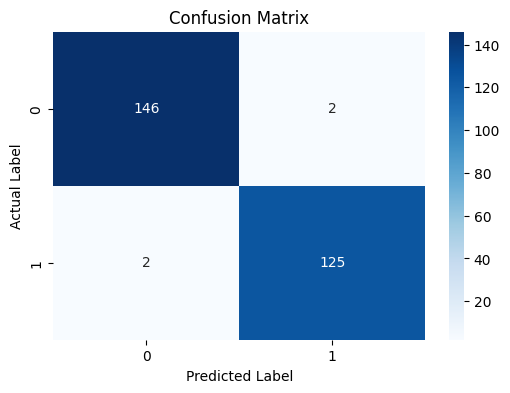

In [ ]:
# ==========================================================
# Task 6: Model Evaluation
# ==========================================================


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt



# Generate predictions

y_pred = []


for sample in X_test:

    prediction = model.predict(sample)

    y_pred.append(prediction)



y_pred = np.array(y_pred)



# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)



# Precision

precision = precision_score(
    y_test,
    y_pred
)



# Recall

recall = recall_score(
    y_test,
    y_pred
)



# F1-score

f1 = f1_score(
    y_test,
    y_pred
)



# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)



print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)


print("\nConfusion Matrix:")
print(cm)



# Plot confusion matrix

plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")


plt.show()

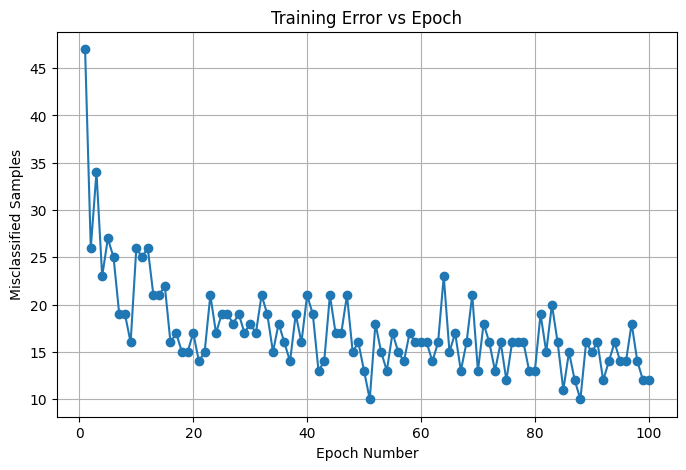

In [ ]:
#Training Error vs Epoch
plt.figure(figsize=(8,5))


plt.plot(
    range(1, len(model.errors_history)+1),
    model.errors_history,
    marker="o"
)


plt.xlabel("Epoch Number")

plt.ylabel("Misclassified Samples")


plt.title(
    "Training Error vs Epoch"
)


plt.grid()

plt.show()

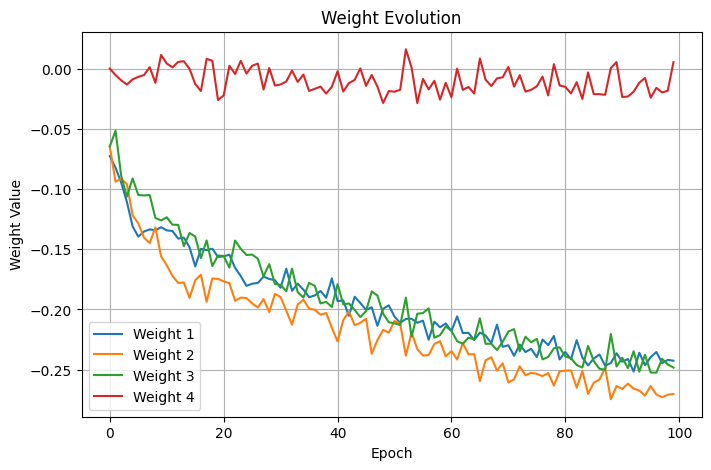

In [ ]:
# 5. Weight Evolution
import numpy as np


weights = np.array(
    model.weights_history
)


plt.figure(figsize=(8,5))


for i in range(weights.shape[1]):

    plt.plot(
        weights[:,i],
        label=f"Weight {i+1}"
    )


plt.xlabel("Epoch")

plt.ylabel("Weight Value")


plt.title(
    "Weight Evolution"
)


plt.legend()

plt.grid()

plt.show()

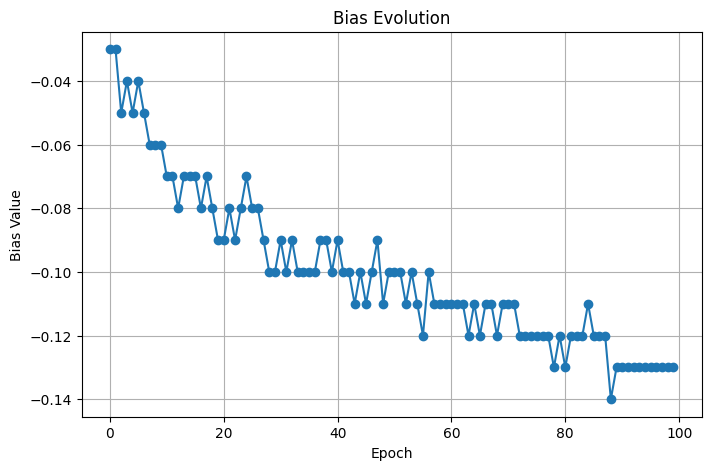

In [ ]:
#Bias Evolution
plt.figure(figsize=(8,5))


plt.plot(
    model.bias_history,
    marker="o"
)


plt.xlabel("Epoch")

plt.ylabel("Bias Value")


plt.title(
    "Bias Evolution"
)


plt.grid()

plt.show()

--------------------------------------
Epoch Number: 1
Misclassified Samples: 47
Updated Weights: [-7.25368818e-03 -6.48626567e-03 -6.44598197e-03  1.98583469e-05]
Updated Bias: -0.003
--------------------------------------
Epoch Number: 2
Misclassified Samples: 26
Updated Weights: [-0.00821701 -0.0093802  -0.00514935 -0.00051824]
Updated Bias: -0.003
--------------------------------------
Epoch Number: 3
Misclassified Samples: 34
Updated Weights: [-0.00946764 -0.00914003 -0.00890554 -0.00095647]
Updated Bias: -0.005
--------------------------------------
Epoch Number: 4
Misclassified Samples: 23
Updated Weights: [-0.01107448 -0.00958088 -0.01063069 -0.00131242]
Updated Bias: -0.004
--------------------------------------
Epoch Number: 5
Misclassified Samples: 27
Updated Weights: [-0.01309639 -0.01217958 -0.00911283 -0.00087707]
Updated Bias: -0.005
--------------------------------------
Epoch Number: 6
Misclassified Samples: 25
Updated Weights: [-0.01395341 -0.01284302 -0.01048817 -0.0

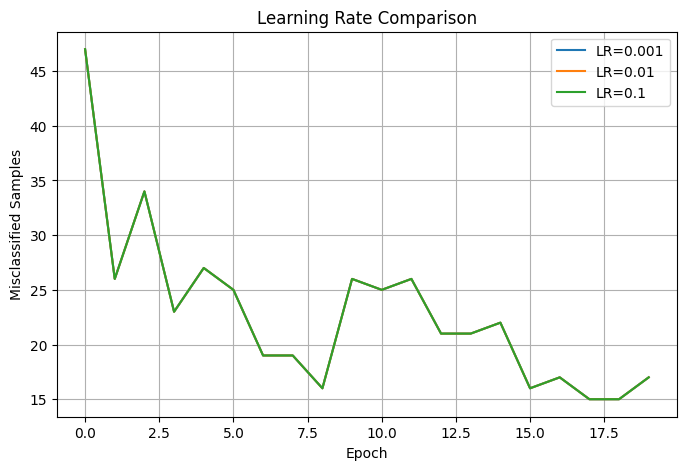

In [ ]:
learning_rates = [
    0.001,
    0.01,
    0.1
]


plt.figure(figsize=(8,5))


for lr in learning_rates:


    temp_model = Perceptron(
        learning_rate=lr,
        epochs=20
    )


    train_perceptron(
        temp_model,
        X_train,
        y_train
    )


    plt.plot(
        temp_model.errors_history,
        label=f"LR={lr}"
    )



plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")


plt.title(
    "Learning Rate Comparison"
)


plt.legend()

plt.grid()

plt.show()

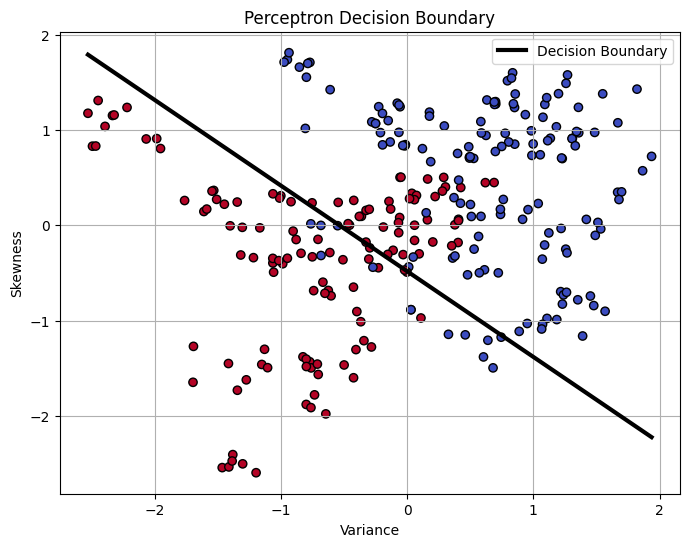

In [ ]:
# ==========================================================
# Decision Boundary with Separating Line
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


# Plot test samples

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=y_test,
    cmap="coolwarm",
    edgecolor="k"
)



# Get learned weights and bias

w1 = model.weights[0]
w2 = model.weights[1]
b = model.bias



# Create x-axis values

x_values = np.linspace(
    X_test[:,0].min(),
    X_test[:,0].max(),
    100
)



# Calculate decision boundary:

# w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b)/w2

if w2 != 0:

    y_values = -(w1*x_values + b) / w2


    plt.plot(
        x_values,
        y_values,
        color="black",
        linewidth=3,
        label="Decision Boundary"
    )



plt.xlabel(
    "Variance"
)

plt.ylabel(
    "Skewness"
)


plt.title(
    "Perceptron Decision Boundary"
)


plt.legend()

plt.grid()

plt.show()


=========== OR Gate ===========

Update 1
Weights = [0. 0.]
Bias = -1


/tmp/ipykernel_1872/2778936372.py:66: RuntimeWarning: divide by zero encountered in scalar divide
  plt.axvline(-b/w[0])


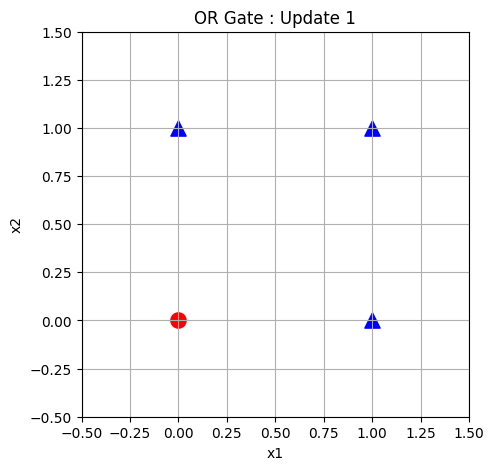


Update 2
Weights = [0. 1.]
Bias = 0


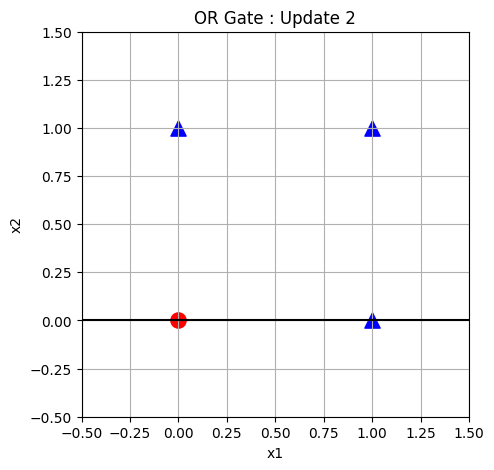


Update 3
Weights = [0. 1.]
Bias = -1


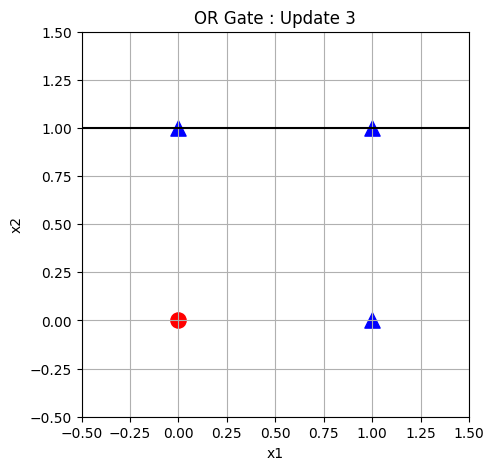


Update 4
Weights = [1. 1.]
Bias = 0


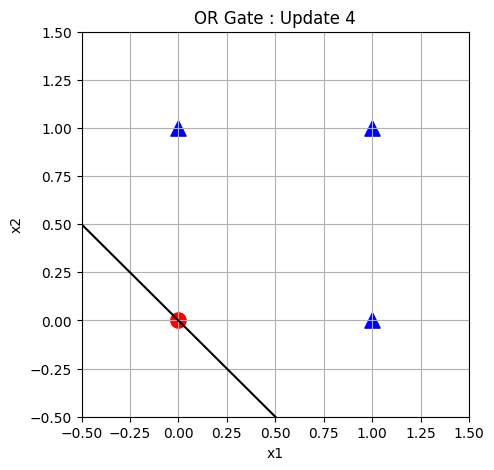


Update 5
Weights = [1. 1.]
Bias = -1


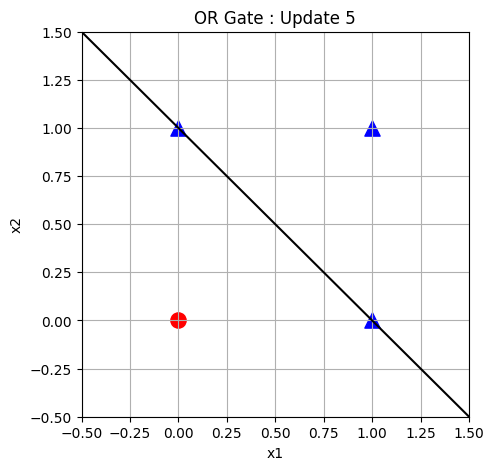


Training Completed!
Final Weights: [1. 1.]
Final Bias: -1

=========== AND Gate ===========

Update 1
Weights = [0. 0.]
Bias = -1


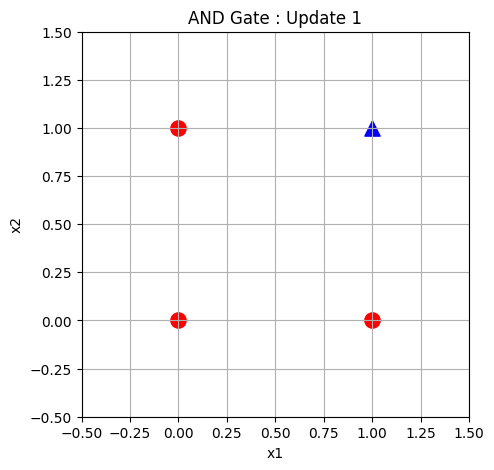


Update 2
Weights = [1. 1.]
Bias = 0


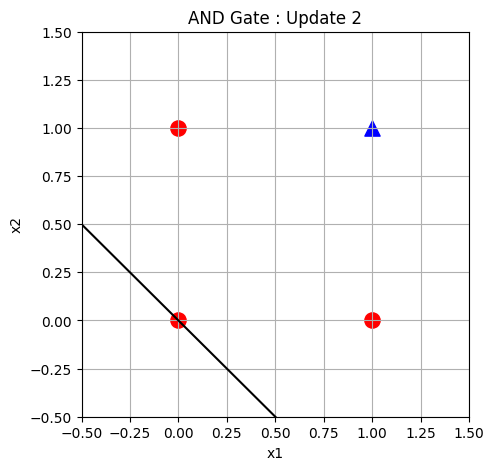


Update 3
Weights = [1. 1.]
Bias = -1


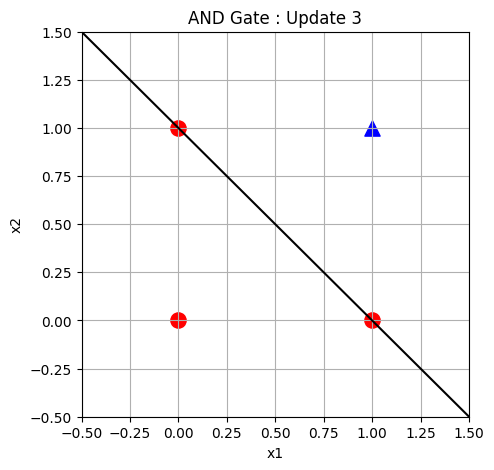


Update 4
Weights = [1. 0.]
Bias = -2


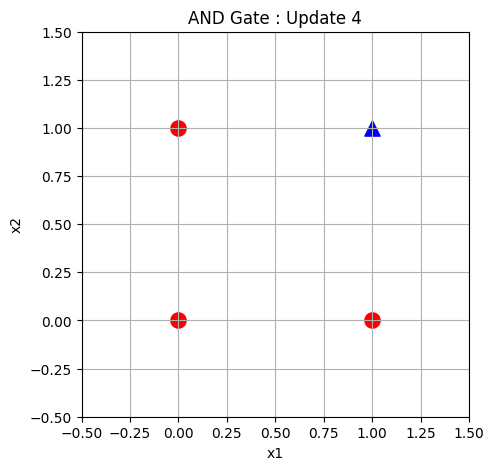


Update 5
Weights = [2. 1.]
Bias = -1


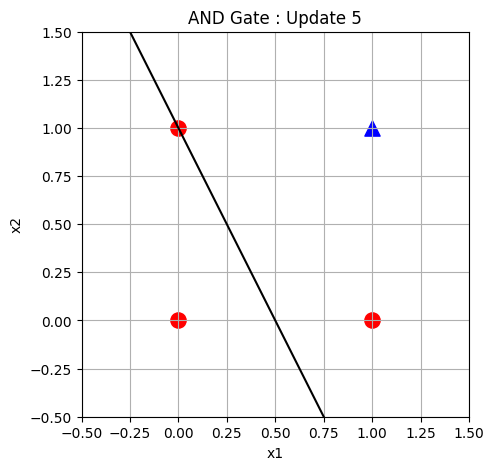


Update 6
Weights = [2. 0.]
Bias = -2


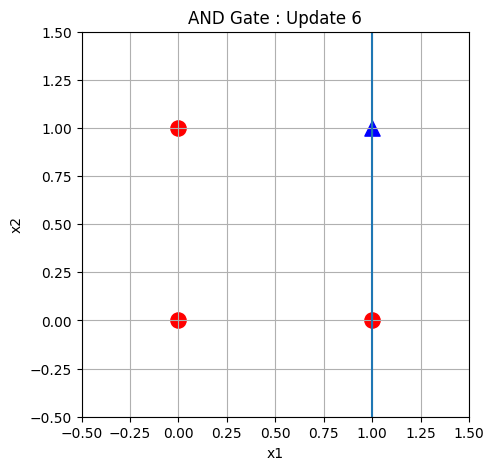


Update 7
Weights = [1. 0.]
Bias = -3


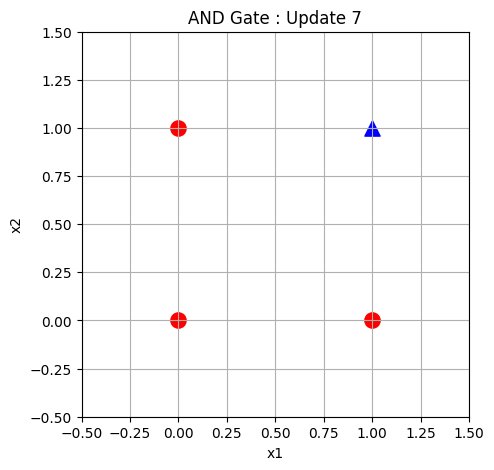


Update 8
Weights = [2. 1.]
Bias = -2


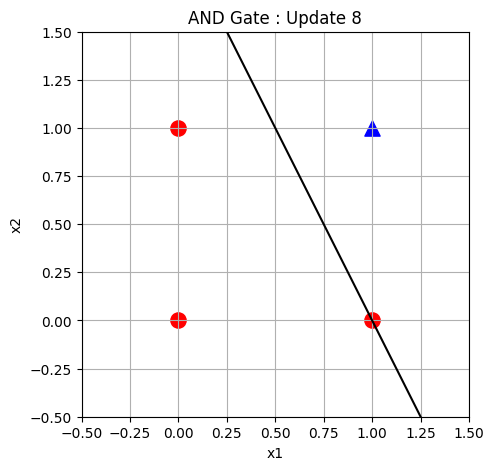


Update 9
Weights = [1. 1.]
Bias = -3


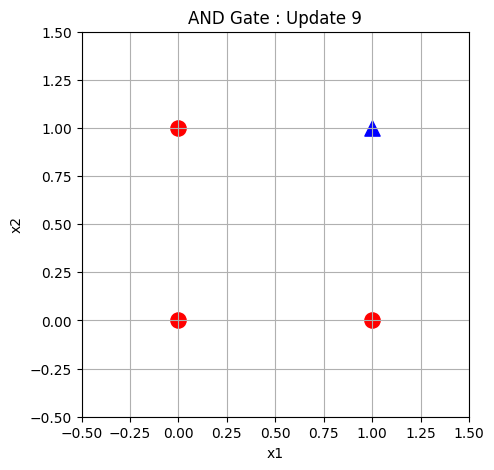


Update 10
Weights = [2. 2.]
Bias = -2


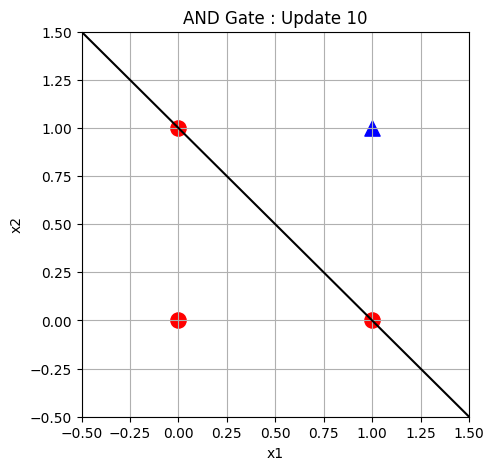


Update 11
Weights = [2. 1.]
Bias = -3


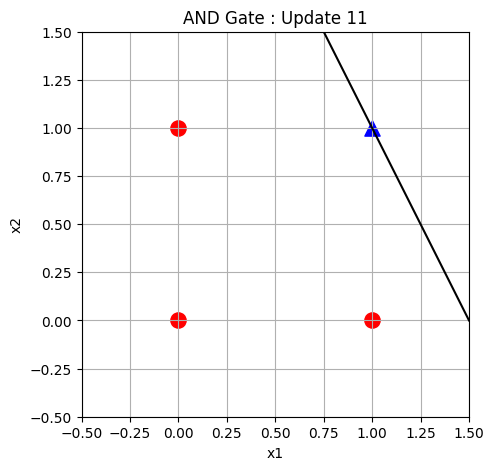


Training Completed!
Final Weights: [2. 1.]
Final Bias: -3

=========== NOT Gate ===========

Update 1
Weight = [-1.]
Bias = -1


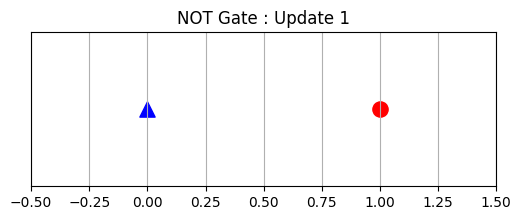


Update 2
Weight = [-1.]
Bias = 0


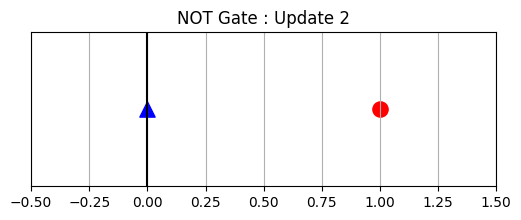


Training Completed!
Final Weight = [-1.]
Final Bias = 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Activation Function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron Training
def perceptron_train(X, y, lr=1, epochs=20, gate="Gate"):
    w = np.zeros(X.shape[1])
    b = 0

    update = 1

    for epoch in range(epochs):
        error_count = 0

        for i in range(len(X)):
            net = np.dot(X[i], w) + b
            pred = step(net)

            error = y[i] - pred

            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                print(f"\nUpdate {update}")
                print("Weights =", w)
                print("Bias =", b)

                plot_boundary(X, y, w, b,
                              f"{gate} : Update {update}")

                update += 1
                error_count += 1

        if error_count == 0:
            print("\nTraining Completed!")
            print("Final Weights:", w)
            print("Final Bias:", b)
            break

    return w, b


# Plot Decision Boundary
def plot_boundary(X, y, w, b, title):

    plt.figure(figsize=(5,5))

    for i in range(len(X)):
        if y[i]==0:
            plt.scatter(X[i][0], X[i][1],
                        color='red', marker='o', s=120)
        else:
            plt.scatter(X[i][0], X[i][1],
                        color='blue', marker='^', s=120)

    x = np.linspace(-0.5,1.5,100)

    if w[1] != 0:
        y_line = -(w[0]*x + b)/w[1]
        plt.plot(x,y_line,'k')
    else:
        plt.axvline(-b/w[0])

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.grid(True)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.show()


# -----------------------------
# OR Gate
# -----------------------------
print("\n=========== OR Gate ===========")

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

perceptron_train(X_or,y_or,gate="OR Gate")


# -----------------------------
# AND Gate
# -----------------------------
print("\n=========== AND Gate ===========")

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

perceptron_train(X_and,y_and,gate="AND Gate")


# -----------------------------
# NOT Gate
# -----------------------------
print("\n=========== NOT Gate ===========")

X_not = np.array([
    [0],
    [1]
])

y_not = np.array([1,0])


def plot_not(X,y,w,b,title):

    plt.figure(figsize=(6,2))

    for i in range(len(X)):
        if y[i]==0:
            plt.scatter(X[i][0],0,color='red',
                        marker='o',s=120)
        else:
            plt.scatter(X[i][0],0,color='blue',
                        marker='^',s=120)

    boundary = -b/w[0]

    plt.axvline(boundary,color='black')

    plt.title(title)
    plt.xlim(-0.5,1.5)
    plt.yticks([])
    plt.grid(True)

    plt.show()


def perceptron_not(X,y):

    w=np.zeros(1)
    b=0

    update=1

    for epoch in range(20):

        error_count=0

        for i in range(len(X)):

            net=np.dot(X[i],w)+b

            pred=step(net)

            error=y[i]-pred

            if error!=0:

                w=w+error*X[i]
                b=b+error

                print("\nUpdate",update)
                print("Weight =",w)
                print("Bias =",b)

                plot_not(X,y,w,b,
                         f"NOT Gate : Update {update}")

                update+=1
                error_count+=1

        if error_count==0:
            print("\nTraining Completed!")
            print("Final Weight =",w)
            print("Final Bias =",b)
            break


perceptron_not(X_not,y_not)


Epoch: 1

Update 1
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0. 0.]
Bias: -1
No decision boundary (weights are zero)


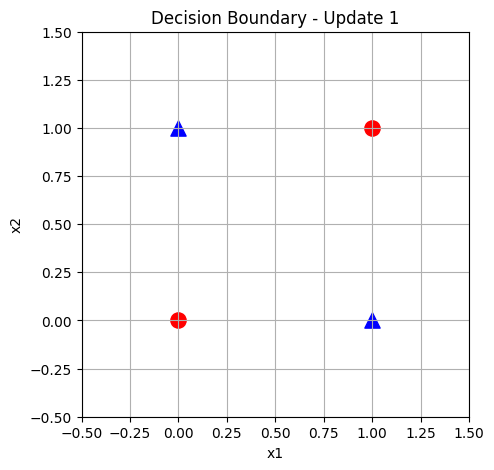


Update 2
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 0


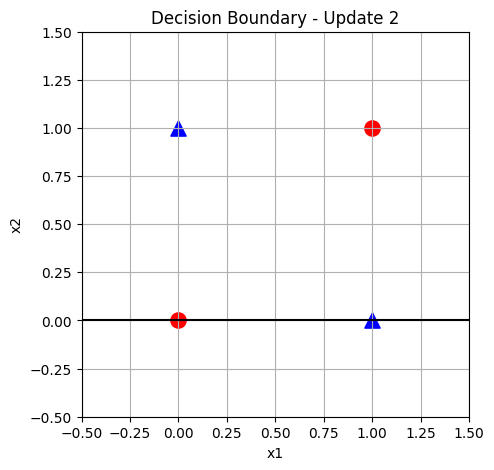


Update 3
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


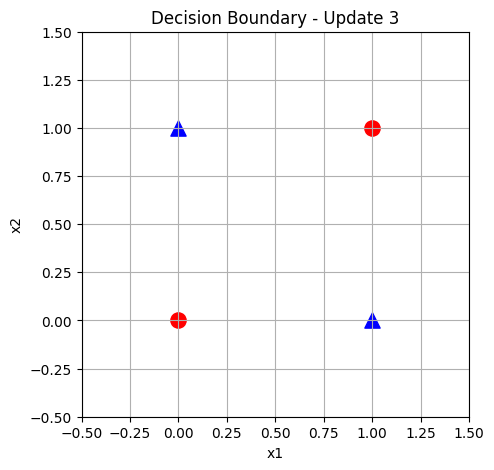


Errors in epoch: 3

Epoch: 2

Update 4
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


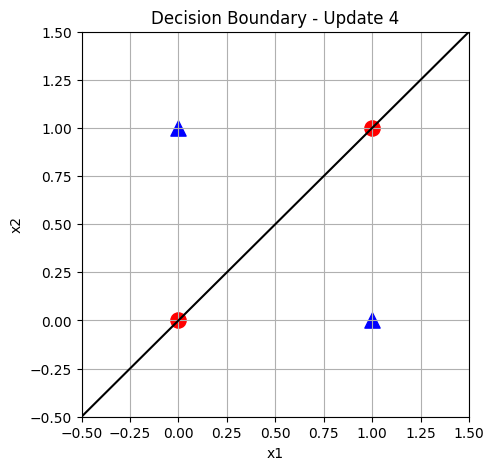


Update 5
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


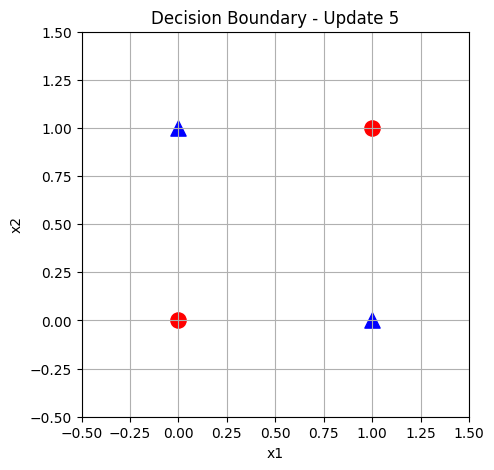


Update 6
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


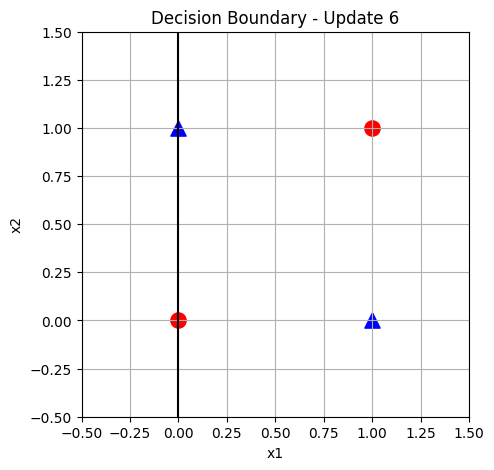


Errors in epoch: 3

Epoch: 3

Update 7
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


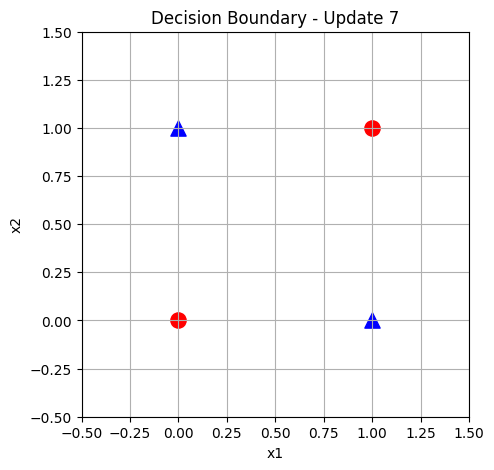


Update 8
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


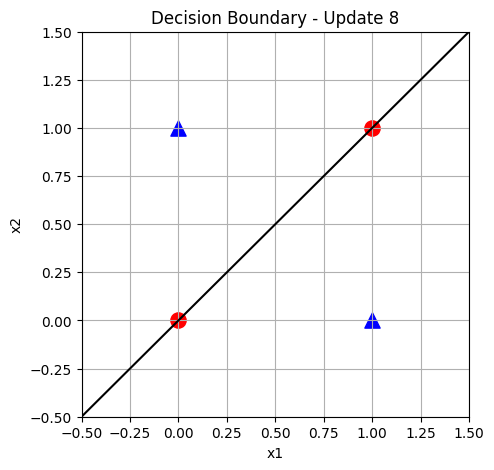


Update 9
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


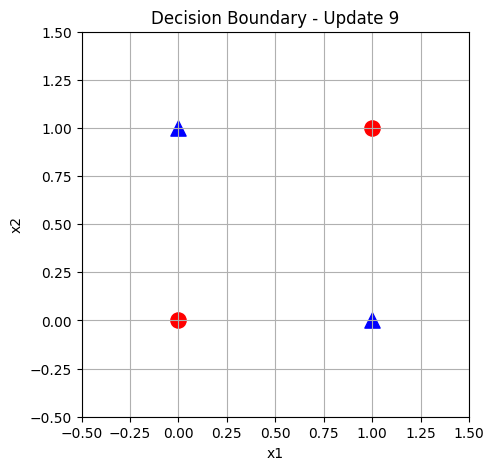


Update 10
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


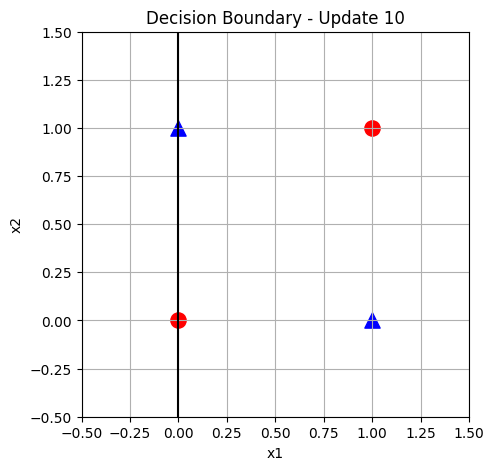


Errors in epoch: 4

Epoch: 4

Update 11
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


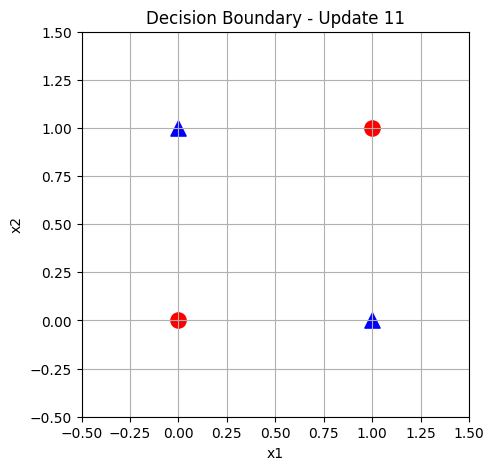


Update 12
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


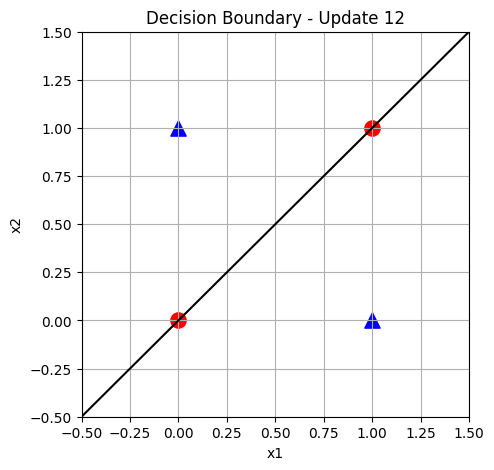


Update 13
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


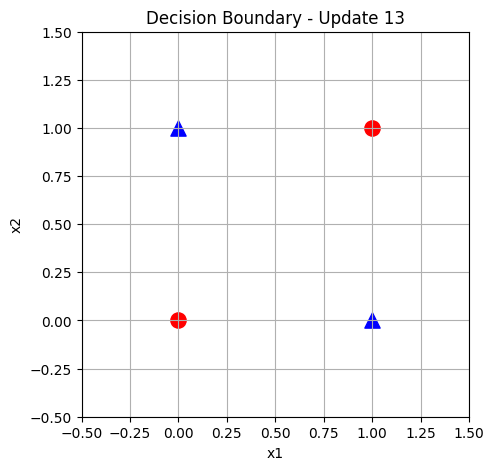


Update 14
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


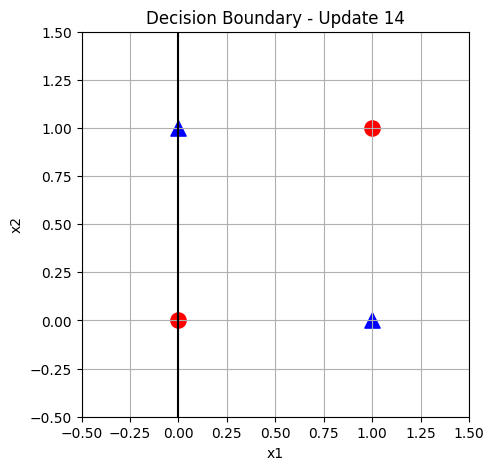


Errors in epoch: 4

Epoch: 5

Update 15
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


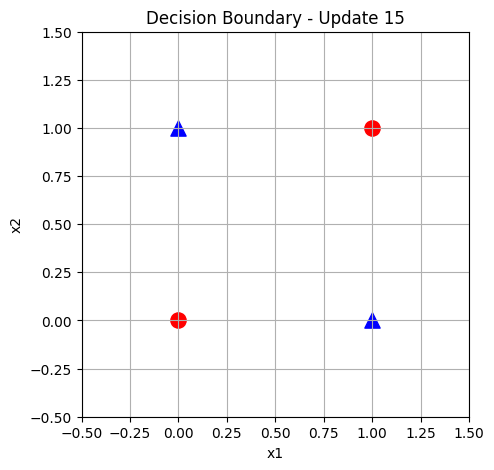


Update 16
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


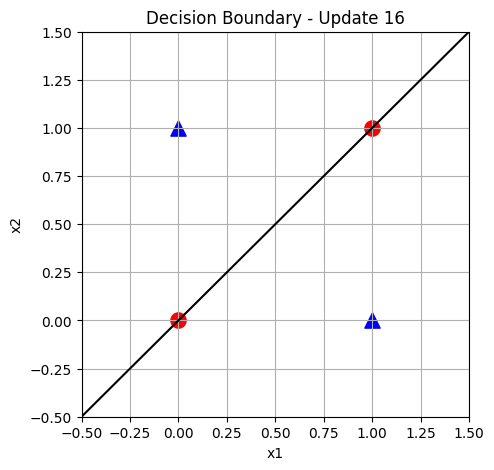


Update 17
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


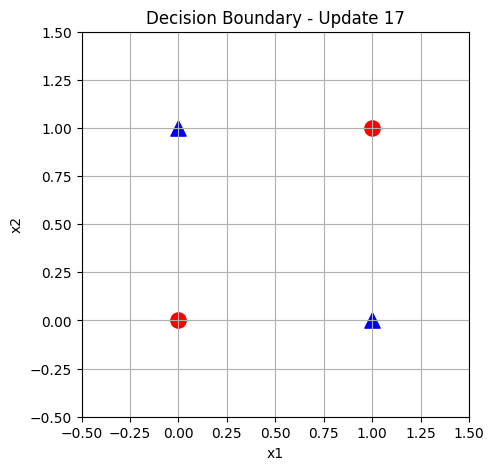


Update 18
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


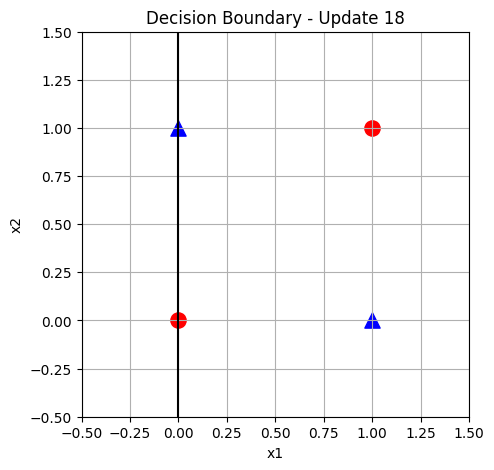


Errors in epoch: 4

Epoch: 6

Update 19
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


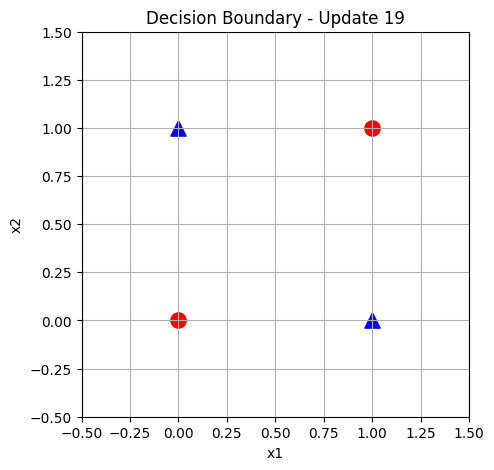


Update 20
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


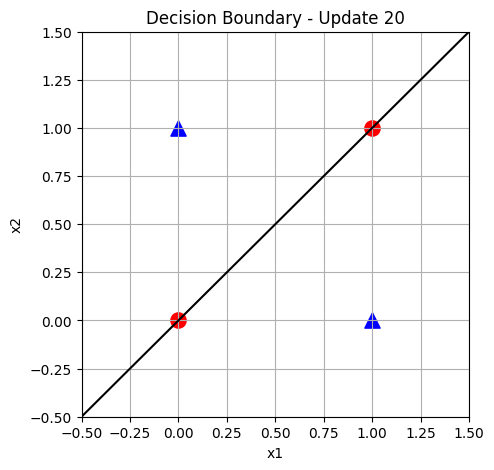


Update 21
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


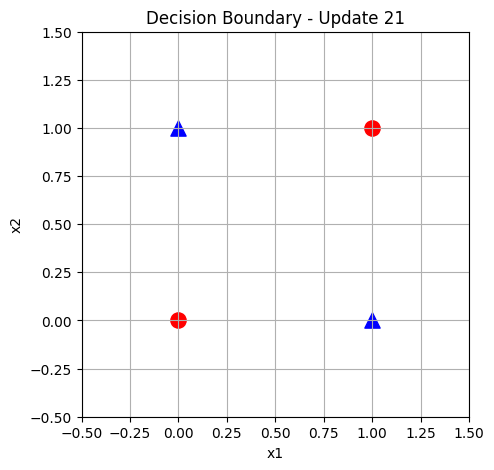


Update 22
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


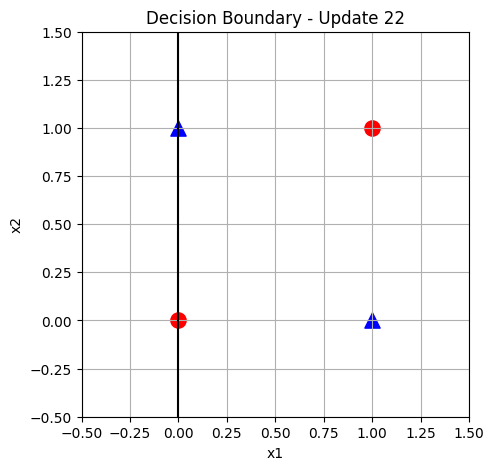


Errors in epoch: 4

Epoch: 7

Update 23
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


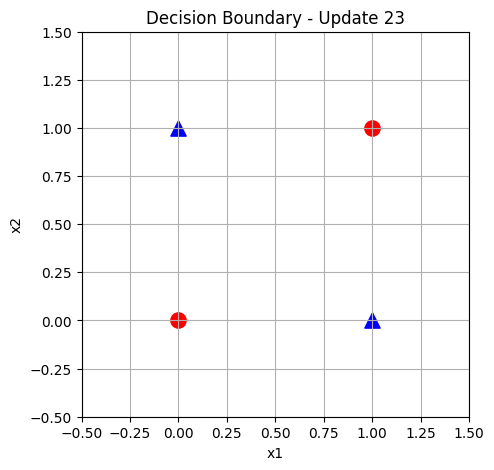


Update 24
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


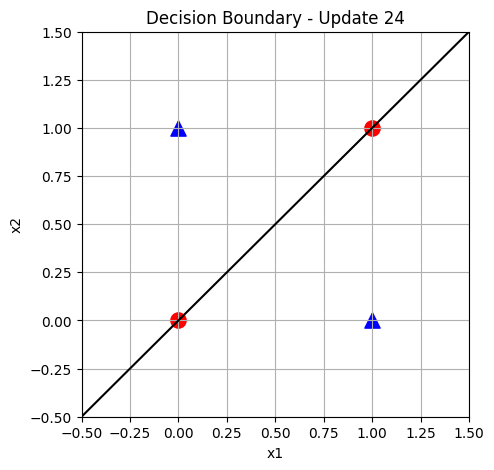


Update 25
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


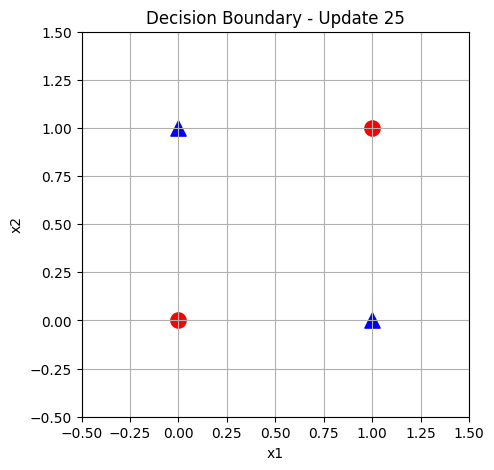


Update 26
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


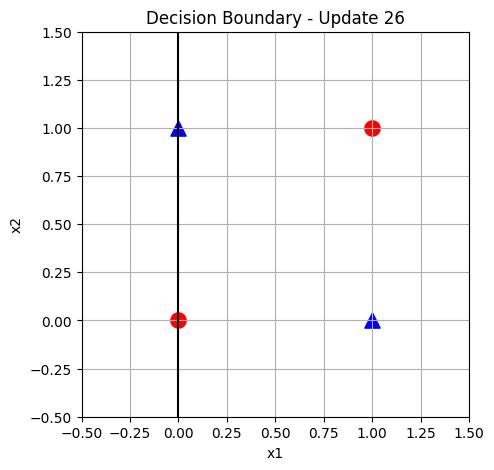


Errors in epoch: 4

Epoch: 8

Update 27
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


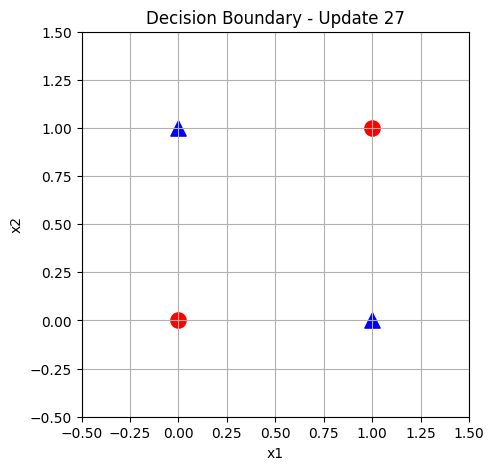


Update 28
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


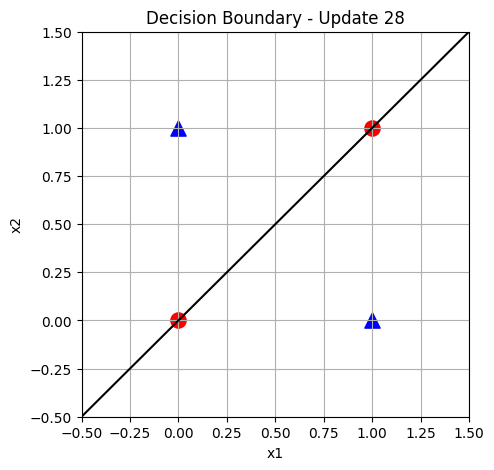


Update 29
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


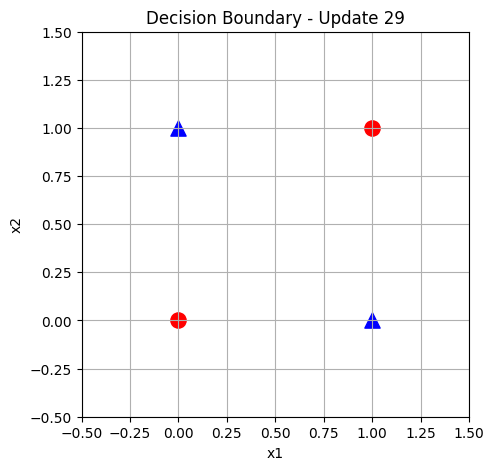


Update 30
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


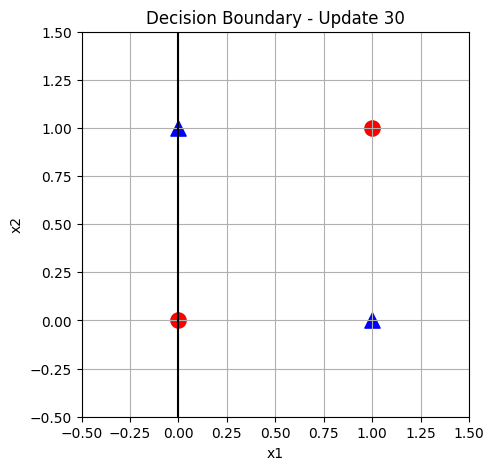


Errors in epoch: 4

Epoch: 9

Update 31
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


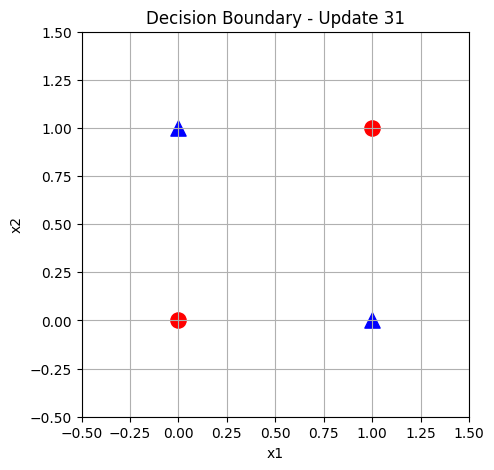


Update 32
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


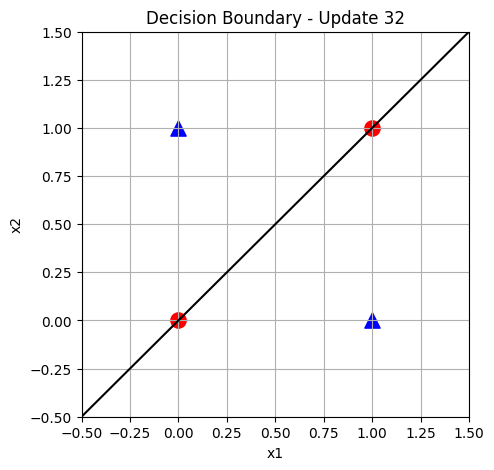


Update 33
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


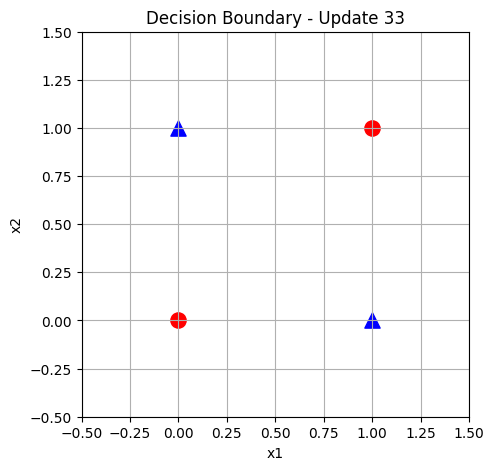


Update 34
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


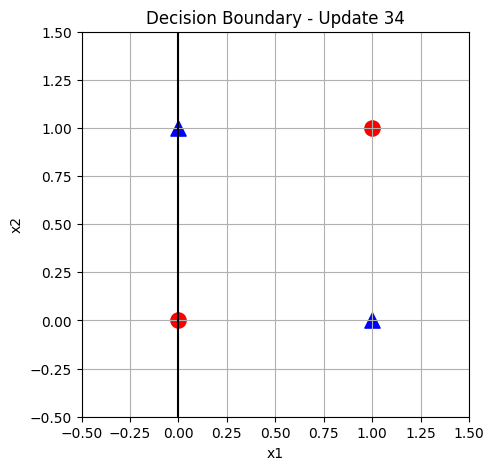


Errors in epoch: 4

Epoch: 10

Update 35
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: -1


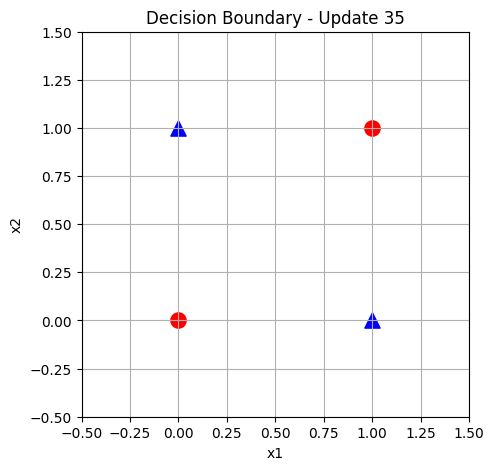


Update 36
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [-1.  1.]
Bias: 0


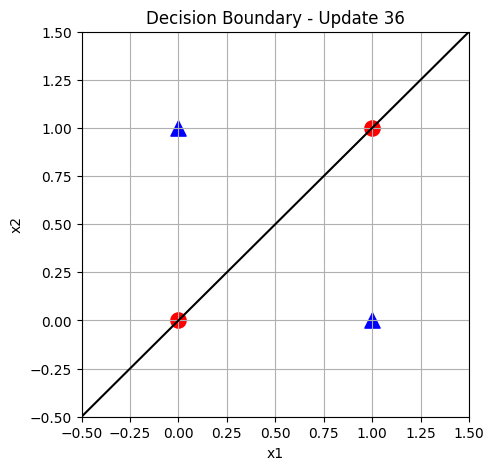


Update 37
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0. 1.]
Bias: 1


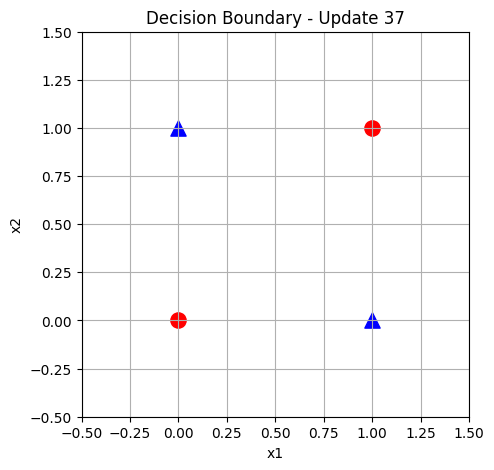


Update 38
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Weights: [-1.  0.]
Bias: 0


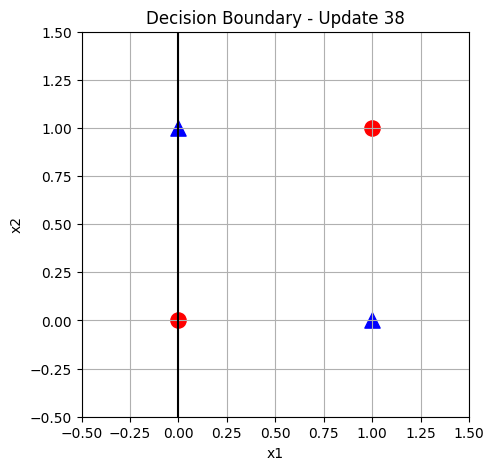


Errors in epoch: 4

Algorithm did NOT converge
Reason: XOR is not linearly separable

Final Weights: [-1.  0.]
Final Bias: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Step Activation Function
def step(x):
    return 1 if x >= 0 else 0


# Plot Decision Boundary
def plot_boundary(X, y, w, b, update):

    plt.figure(figsize=(5,5))

    # Plot points
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1],
                        color='red',
                        marker='o',
                        s=120,
                        label="Class 0" if i==0 else "")
        else:
            plt.scatter(X[i][0], X[i][1],
                        color='blue',
                        marker='^',
                        s=120,
                        label="Class 1" if i==1 else "")


    x = np.linspace(-0.5,1.5,100)


    # Draw decision boundary
    if w[0] == 0 and w[1] == 0:
        print("No decision boundary (weights are zero)")

    elif w[1] != 0:
        y_line = -(w[0]*x+b)/w[1]
        plt.plot(x,y_line,'black')

    else:
        plt.axvline(-b/w[0],color='black')


    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Decision Boundary - Update {update}")
    plt.grid(True)
    plt.show()



# Perceptron for XOR
def xor_perceptron(X,y,lr=1,epochs=10):

    # Initialize weights
    w = np.zeros(2)
    b = 0

    update = 1


    for epoch in range(epochs):

        print("\n================")
        print("Epoch:",epoch+1)
        print("================")


        error_count = 0


        for i in range(len(X)):


            # Calculate output
            net = np.dot(X[i],w)+b

            prediction = step(net)


            # Calculate error
            error = y[i]-prediction


            if error != 0:

                # Weight update
                w = w + lr*error*X[i]

                # Bias update
                b = b + lr*error


                print("\nUpdate",update)
                print("Input:",X[i])
                print("Target:",y[i])
                print("Prediction:",prediction)
                print("Error:",error)
                print("Weights:",w)
                print("Bias:",b)


                plot_boundary(X,y,w,b,update)


                update += 1
                error_count += 1



        print("\nErrors in epoch:",error_count)


        # Check convergence
        if error_count == 0:
            print("\nAlgorithm Converged")
            break


    if error_count != 0:
        print("\nAlgorithm did NOT converge")
        print("Reason: XOR is not linearly separable")


    print("\nFinal Weights:",w)
    print("Final Bias:",b)



# XOR Dataset

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y = np.array([
    0,
    1,
    1,
    0
])


# Run XOR perceptron
xor_perceptron(X,y,epochs=10)